But du Notebook

Vérifier la qualité des données du projet. Réaliser un feature engineering

# 1. Initialisation

## 1.1 Package 

In [177]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Pour la suite
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

## 1.2 Fonction

# 2. Données

## 2.1 Importation 

Chemins des dossiers

In [17]:
input_directory = r"./data/raw/"
out_directory = r"./data/prepared/"

Noms des fichiers

In [18]:
os.listdir(input_directory)

['.ipynb_checkpoints',
 'application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'HomeCredit_columns_description.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'sample_submission.csv']

In [19]:
files_name = {"test" : "application_test.csv",
              "train" : "application_train.csv"}

Importation

In [20]:
train = pd.read_csv(os.path.join(input_directory, files_name["train"]))
test = pd.read_csv(os.path.join(input_directory, files_name["test"]))

# 3. Qualité de la données

## 3.1 Contenue des dataframes

## Dataset train

In [116]:
train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

Le dataset train est composé de 307.511 ligne et 122 colonne.  
Ces colonnes sont répartie en fonction des type de données qu'elles contiennent:
- 41 contiennent des données de type int, des nombres entier.
- 65 contiennent des données de type float des nombres décimaux.
- 16 contiennent des données de type object des shaine de caractère (str).

Les variables des colonnes contenant des entier sont des features quantitatives discrets ordonnées ou non.  
Les variables des colonnes contenant des décimaux sont des features quantitatives continus.
Les variables des colonnes contenant des chaîne de caractères sont des features qualitative ordonner ou non.  

De plus, ce dataset étant celui d'entraînement, il contient la variable à prédire `TARGET`, si le client as remboursé sont prêt ou non.  

On observe aussi qu'une partie des colonnes comporte des valeurs null.

- Selon la documentation, la variable `SK_ID_CURR` est un identifiant unique pour chaque prêt, un pour chaque ligne. Si c'est le cas alors le nombre de valeurs unique dans cette feature doit être égale au nombre de ligne du dataset.

In [117]:
len(train["SK_ID_CURR"].unique())

307511

## Dataset test

In [118]:
test.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDUCATION_TYPE           48744 non-null

Le dataset train est composé de 48744 ligne et 121 colonne.  
Ces colonnes sont répartie en fonction des type de données qu'elles contiennent:
- 40 contiennent des données de type int, des nombres entier.
- 65 contiennent des données de type float des nombres décimaux.
- 16 contiennent des données de type object des shaine de caractère (str).

Les variables des colonnes contenant des entier sont des features quantitatives discrets ordonnées ou non.  
Les variables des colonnes contenant des décimaux sont des features quantitatives continus.
Les variables des colonnes contenant des chaîne de caractères sont des features qualitative ordonner ou non.  

De plus, ce dataset étant celui de test, il ne contient pas la variable à prédire `TARGET`. Ce qui explique le décalage d'une colonne entre les deux dataset  

Comme pour le dataset de train, On observe aussi qu'une partie des colonnes comporte des valeurs null.

- Selon la documentation, la variable `SK_ID_CURR` est un identifiant unique pour chaque prêt, un pour chaque ligne. Si c'est le cas alors le nombre de valeurs unique dans cette feature doit être égale au nombre de ligne du dataset.

In [119]:
len(test["SK_ID_CURR"].unique())

48744

Le nombre de valeurs est bien identique au nombre de ligne du dataframe. Donc `SK_ID_CURR` est la clé primaire de ce dataframe que j'utiliserait pour le fusionner avec les autres dataset de  la base de données.

- Est-ce que des valeurs de `SK_ID_CURR` ce retrouver entre les deux dataframe ?

In [120]:
pd.merge(train, test, on="SK_ID_CURR", how="inner")

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER_x,FLAG_OWN_CAR_x,FLAG_OWN_REALTY_x,CNT_CHILDREN_x,AMT_INCOME_TOTAL_x,AMT_CREDIT_x,AMT_ANNUITY_x,...,FLAG_DOCUMENT_18_y,FLAG_DOCUMENT_19_y,FLAG_DOCUMENT_20_y,FLAG_DOCUMENT_21_y,AMT_REQ_CREDIT_BUREAU_HOUR_y,AMT_REQ_CREDIT_BUREAU_DAY_y,AMT_REQ_CREDIT_BUREAU_WEEK_y,AMT_REQ_CREDIT_BUREAU_MON_y,AMT_REQ_CREDIT_BUREAU_QRT_y,AMT_REQ_CREDIT_BUREAU_YEAR_y


Le dataset renvoiyer quand je réalise la fusion des deux comprend 0 ligne et 242 colonne. Sachant que 0 lignes on été renvoyer, je peut dire que aucune valeurs de `SK_ID_CURR` n'est partager par les deux dataset. De plus, le nombre de colonne est de 242, c'est à dire 121*2+1, je peut donc dire les colonnes des deux dataframe partage les mêmes noms en dehors de `TARGET` ce qui est attendue.

- Quel pourcentage de données total entre les deux dataset ?

Sur un total de 356.255 prêt le dataset :
- tain contient 86.32% des ligne
- test contient 13.68% des ligne

On n'as donc pas une proportion classique entre jeu d'entraînement et de test qui est habituellement de 80:20.

## 3.2 Equilibre de la feature `TARGET`

Un déséquilibre de la variable cible lors d'un apprentissage superviser peut provoquer des biais dans les prévisions du modèle. Ces déséquilibres entre classe doivent être détecter et prit en compte lors de la phase d'étude.

In [122]:
train["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

On observe un très fort déséquilibre entre les deux classe qui compose la cible.
- 92% des prêt du dataset on été remboursés.
- 8% des prêt non pas été remboursés.

C'est un très fort déséquilibre qui devras être corriger pour assurer une bonne capacité de prévision du modèle.

## 3.3 Equilibre d'autre features

In [169]:
def graph_desequilibre(df, feature, target, name):
    '''
    Tracer les graphs de densité d'une variable qualitative pour tous le jeux de données puis en fonction des deux classe d'une vraibale à expliquer.
    '''
    fig, axes = plt.subplots(2, 2, sharex=False, sharey=True, figsize=(10, 8))

    masks = {"all" : feature,
             "empty" : np.nan}
    for classe in df[target].unique():
        masks[str(classe)] = df[target] == classe

    #bins = len(df[target].unique())
    for idx, (ax, key) in enumerate(zip(axes.ravel(),masks.keys())):
        
        if key == "all":
            ax.hist(df[masks[key]
                      ], density=True)
            ax.set_title(f"Répartition de {feature} dans tous le dataset")

        elif key != "empty":

            ax.hist(df.loc[masks[key], feature], density=True)
            ax.set_title(f"Répartition de {feature} pour la valeurs cible {key}")
            
        
    # Ajuster le graphique pour optimisé la place utilisée
    fig.subplots_adjust(wspace=0.1, hspace=0.25, left=0.025, right=0.975, bottom=0.2, top=0.82)
    # Ajouter le titre
    fig.text(
        x=0.5,
        y=0.88,
        s=f"Equilibre de la variable {target} dans le dataset {name}",
        ha="center",
        va="center",
        ma="center",
        fontsize=20
    )

    plt.show()
    plt.close()

### Equilivre de `CODE_GENDER`

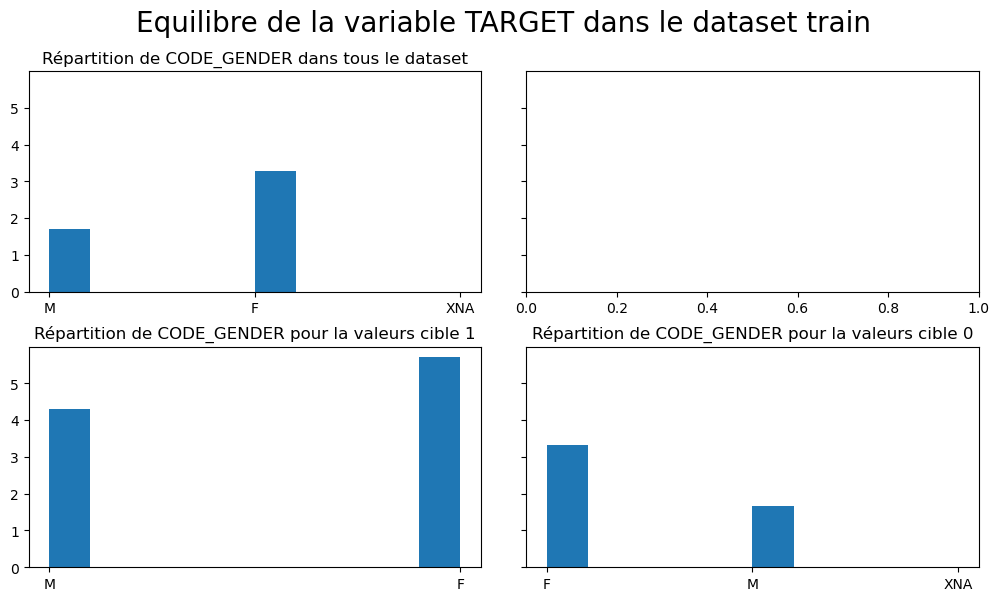

In [170]:
graph_desequilibre(train, "CODE_GENDER", "TARGET", "train")

On observe un déséquilibre pour la feature `CODE_GENDER`. La majorité des prêts on été contracter par des femme. Mais cette différence ce retrouve aussi dans les sous catégorie former par la valeurs la cible. Il est possible que notre modèle produissent de meilleur prévision si le client est une femme.

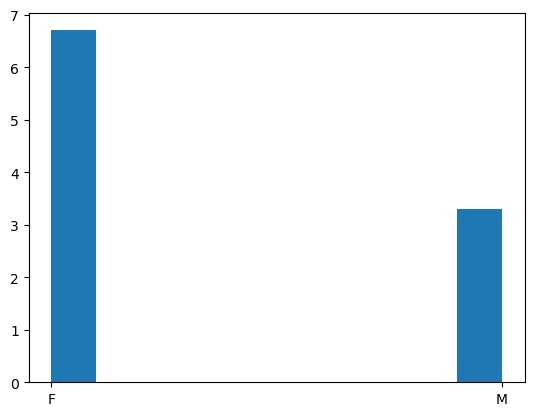

In [171]:
plt.hist(test["CODE_GENDER"], density=True)
plt.show()

Le même déséquilibre ce retrouve dans le dataset de test.

### Equilibe de `NAME_CONTRACT_TYPE`

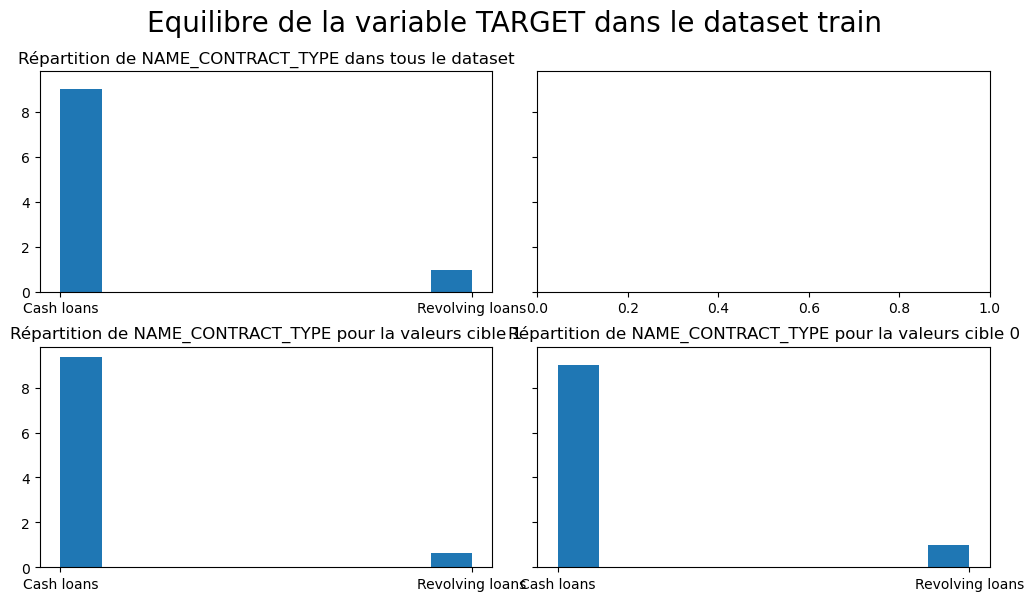

In [172]:
graph_desequilibre(train, 'NAME_CONTRACT_TYPE', "TARGET", "train")

La majorité des prêts contractés dans la base de données sont des prêts de type `Cash loans`. Ainsi on peut s'attendre a ce que le modèle ai des difficulté a prévoir correctement les remboursement pour des crédit de type `Revolving loans`.

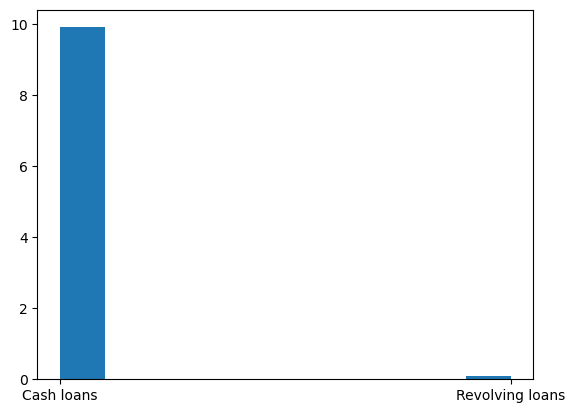

In [173]:
plt.hist(test["NAME_CONTRACT_TYPE"], density=True)
plt.show()

Ce déséquilibre est encore plus important dans le cas du dataset de test.

### Equilibre de `CNT_CHILDREN`

In [174]:
len(train["CNT_CHILDREN"].unique())

15

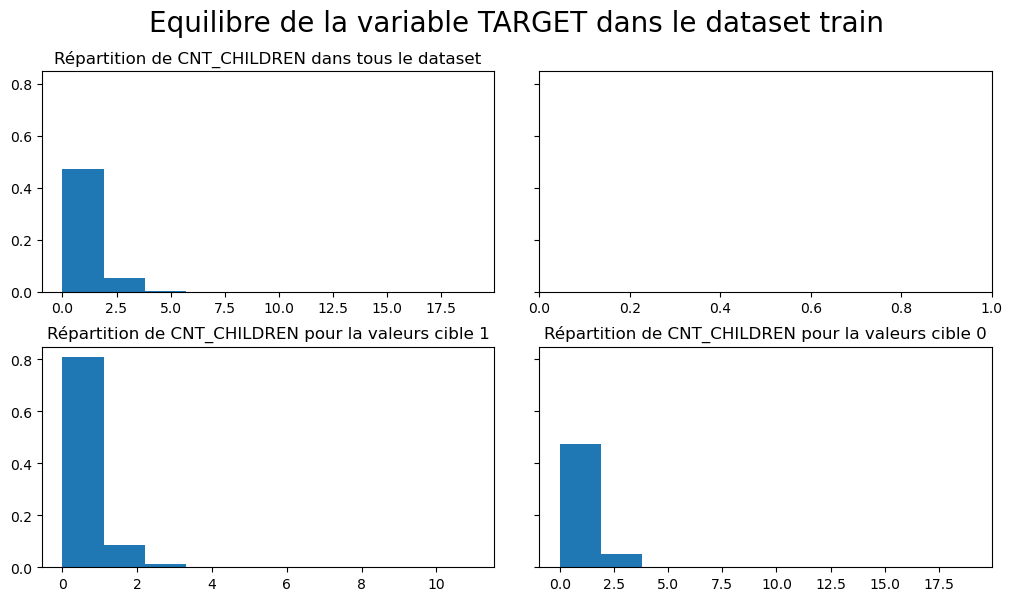

In [175]:
graph_desequilibre(train, "CNT_CHILDREN", "TARGET", "train")

La majoité des client ayant contracter un prêt on 0 ou 1 enfant. IL est trés rare qu'il en ai plus. Dans ce cas on a un déséquilibre qui pourrait être corriger en regroupant les vaelrus supérueyr à 2 dans une catégorie 3 enfant et plus.

## 3.4 Missing values 

La majorité des modèles ne fonctionne pas si les données utilisées pour leurs entraînement contiennent des données Null.

In [181]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

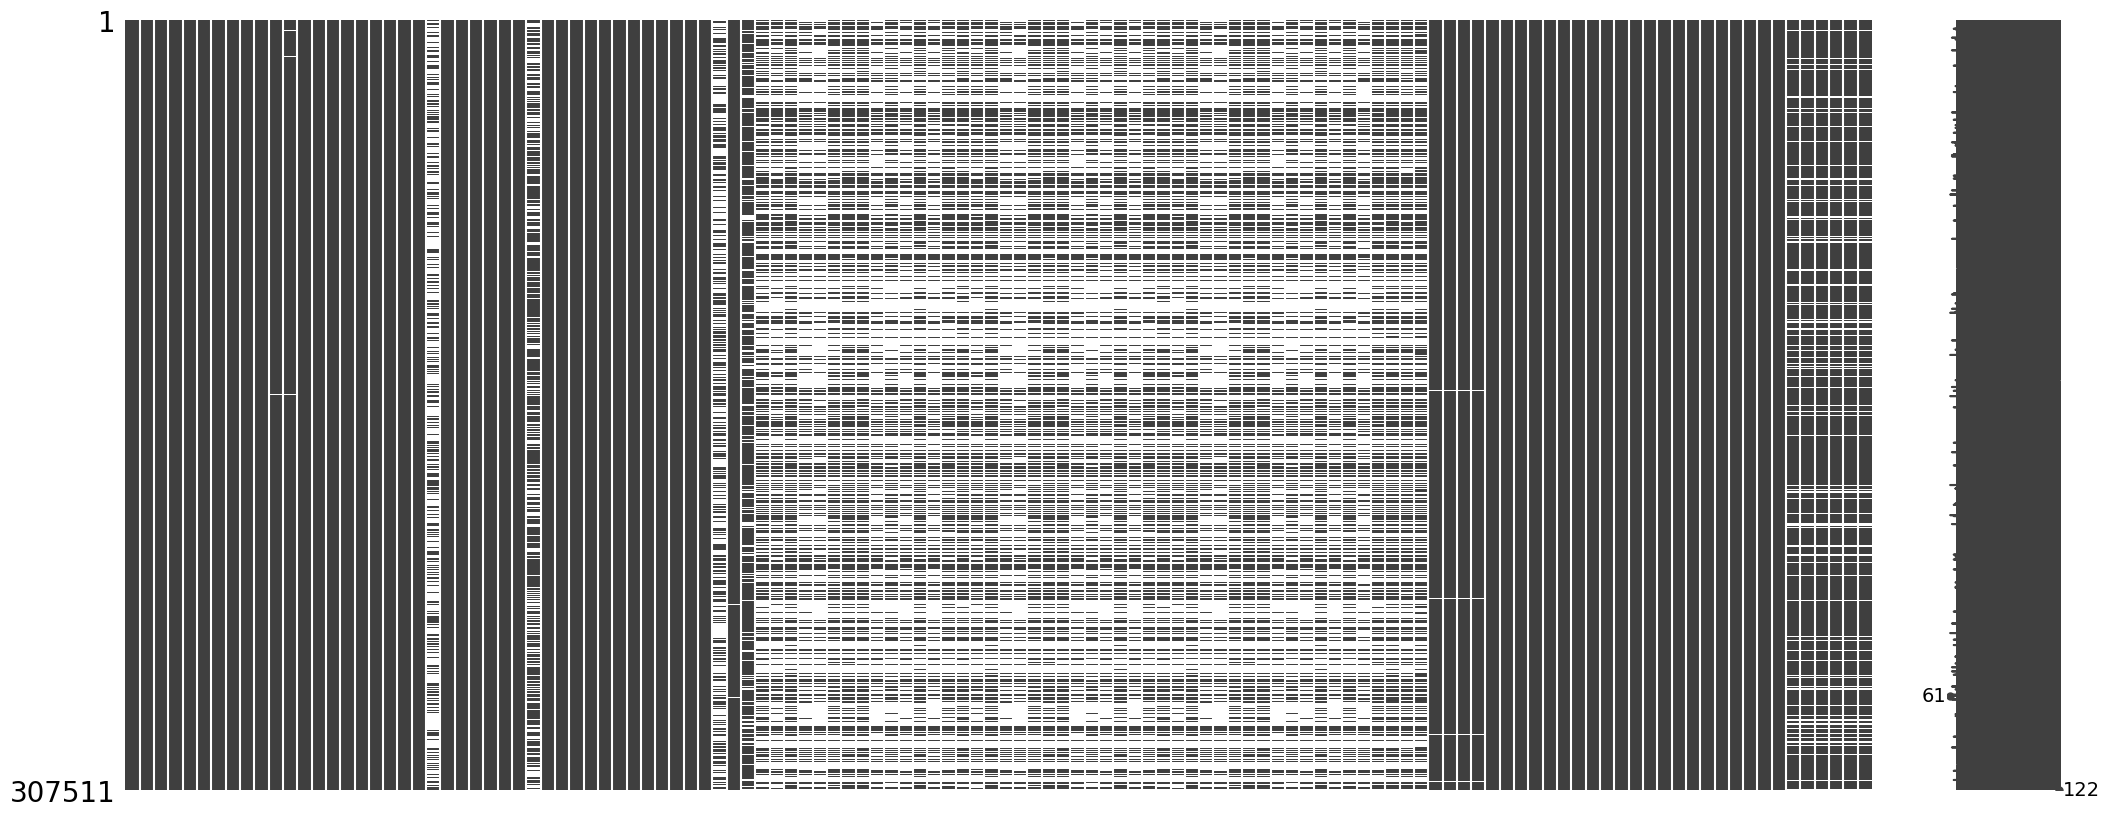

In [178]:
msno.matrix(train)
plt.show()

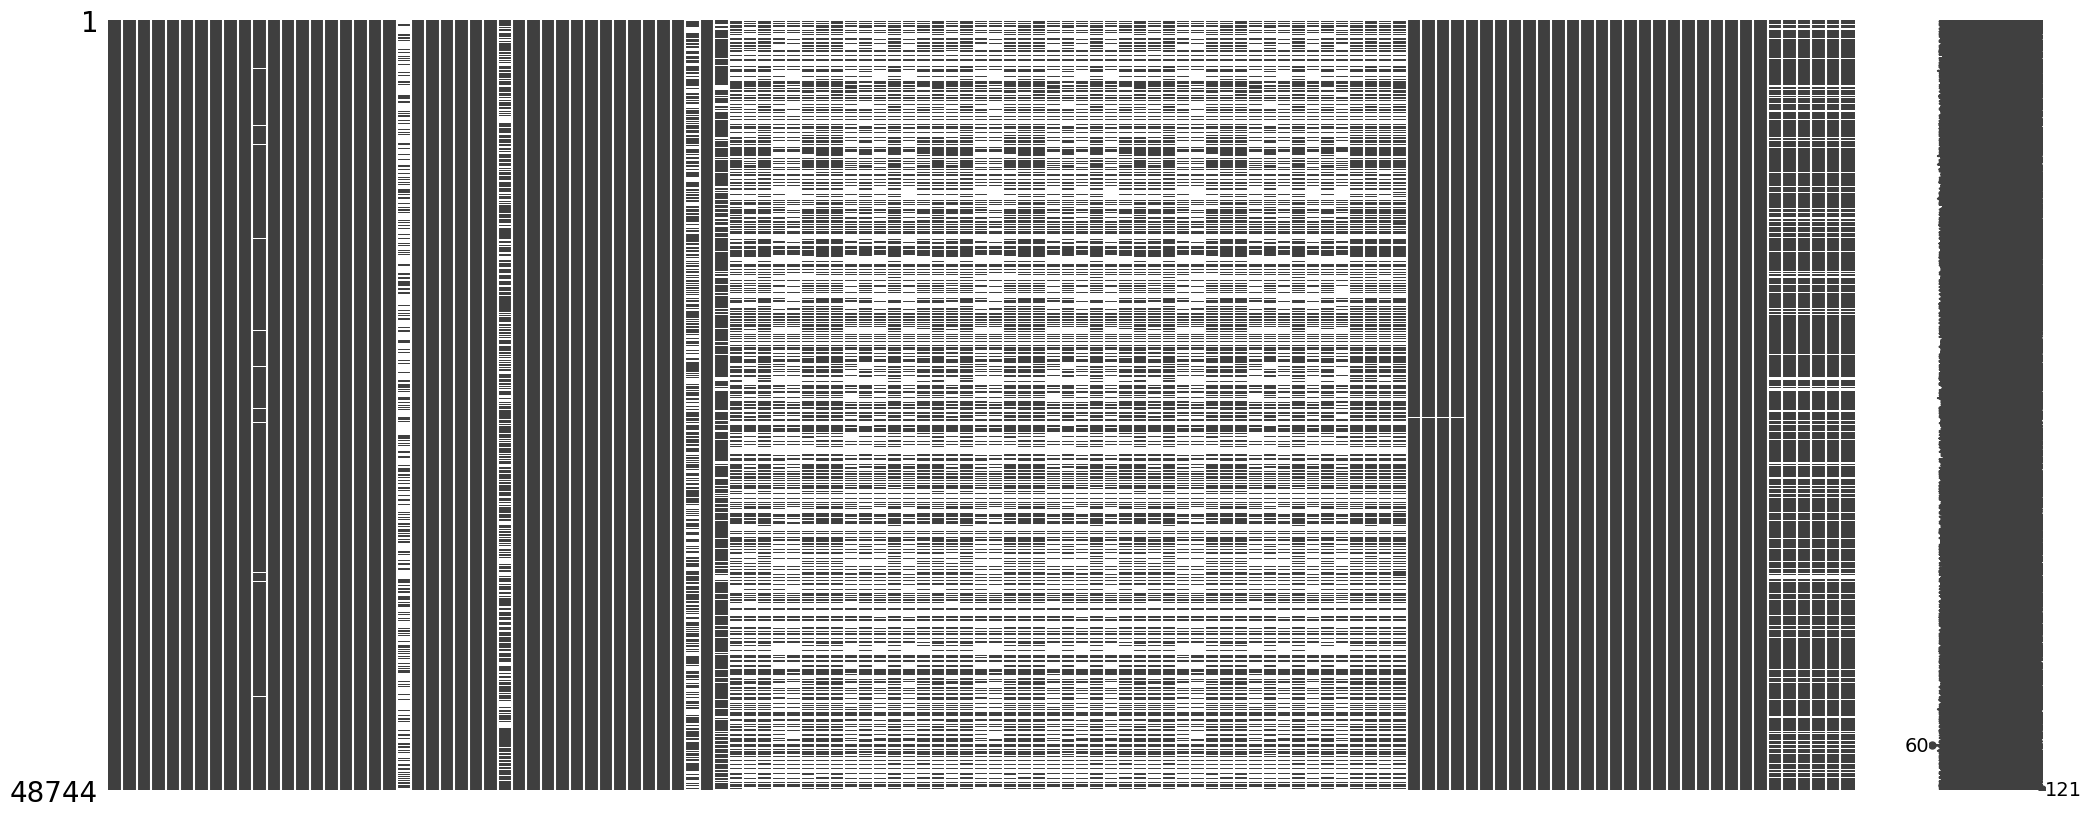

In [179]:
msno.matrix(test)
plt.show()

La majorité des colonnes avec des valeurs manquantes sont au centre du dataframe.

In [182]:
# Missing values statistics
missing_values = missing_values_table(train)
missing_values.head(60)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


Une partie des colonnes correspondent à des features qui sont associées à d'autre comme des informations sur le bien posséder, la voiture. Etant donné que le client du prêt n'as pas de bien il est normale que ces valeurs soit vide. Pour ce features ci une imputation spécifique peut être utilisé.

## 3.5 Détaille des features qualitative

In [183]:
# Nombre de classe unique dans chacune des feature qualitatives
train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [184]:
# Nombre de classe unique dans chacune des feature qualitatives
test.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               7
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             5
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [234]:
# Nombre de classe unique dans chacune des feature qualitatives
temp1 = train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)
temp1 = temp1.rename("train")

In [235]:
# Nombre de classe unique dans chacune des feature qualitatives
temp2 = test.select_dtypes('object').apply(pd.Series.nunique, axis = 0)
temp2 = temp2.rename("test")

In [238]:
temp = pd.concat([temp1, temp2], axis=1)

In [239]:
temp["diff"] = temp["train"] - temp["test"]

In [240]:
display(temp)

,train,test,diff
NAME_CONTRACT_TYPE,2,2,0
CODE_GENDER,2,2,0
FLAG_OWN_CAR,2,2,0
FLAG_OWN_REALTY,2,2,0
NAME_TYPE_SUITE,7,7,0
NAME_INCOME_TYPE,8,7,1
NAME_EDUCATION_TYPE,5,5,0
NAME_FAMILY_STATUS,6,5,1
NAME_HOUSING_TYPE,6,6,0
OCCUPATION_TYPE,18,18,0


On retrouve une catégorie supplémentaire pour `CODE_GENDER` dans le jeux de train, en fonction du nombre de ligne concerner on pourras simplement les supprimer.  
On trouve aussi une catégorie en plus pour `NAME_INCOME_TYPE` et `NAME_FAMILY_STATUS`

- `CODE_GENDER`

In [192]:
train["CODE_GENDER"].value_counts()

CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64

On observe quatre ligne avec une valeurs de `CODE_GENDER` égale à XNA. C'est trés peux je vais les supprimer.

In [189]:
drop_index = train.loc[train["CODE_GENDER"] == "XNA"].index
train = train.drop(drop_index)
del drop_index

In [190]:
train.shape

(307507, 122)

- `NAME_INCOME_TYPE`

In [248]:
train["NAME_INCOME_TYPE"].value_counts().sort_index()

NAME_INCOME_TYPE
Businessman                 10
Commercial associate     71616
Maternity leave              5
Pensioner                55362
State servant            21703
Student                     18
Unemployed                  22
Working                 158771
Name: count, dtype: int64

In [249]:
test["NAME_INCOME_TYPE"].value_counts().sort_index()

NAME_INCOME_TYPE
Businessman                 1
Commercial associate    11402
Pensioner                9273
State servant            3532
Student                     2
Unemployed                  1
Working                 24533
Name: count, dtype: int64

La catégorie supplémentaire et "maternity leave". Catégorie qui est représenté 5 fois dans le jeux de train. retiré ces itérations ?  
De plus on oberver un fort déséquilibre entre les différentes catégories de cette variable

- `NAME_FAMILY_STATUS`

In [250]:
train["NAME_FAMILY_STATUS"].value_counts().sort_index()

NAME_FAMILY_STATUS
Civil marriage           29774
Married                 196429
Separated                19770
Single / not married     45444
Unknown                      2
Widow                    16088
Name: count, dtype: int64

In [251]:
test["NAME_FAMILY_STATUS"].value_counts().sort_index()

NAME_FAMILY_STATUS
Civil marriage           4261
Married                 32283
Separated                2955
Single / not married     7036
Widow                    2209
Name: count, dtype: int64

La catégorie supplémentaire et "Unknown". Catégorie qui est représenté 2 fois dans le jeux de train. Je pense que je peut retiré cette catégorie.

In [252]:
drop_index = train.loc[train["NAME_FAMILY_STATUS"] == "Unknown"].index
train = train.drop(drop_index)
del drop_index

## 3.6 Anomalies

Il arrive que les features comportes des valeurs qui sont aberrante, c'est à dire qui sont clairement des erreur au regard de la features et des autres valeurs qui la compose. Je vais chercher à identifier ces anomalies dans les colonne de type float. Je ne vais pas pouvoir balayer les 64 feature et vais donc me concentré sur un sous ensemble.

### `DAYS_BIRTH`  
Ou Age de l'emprinteur au moment du prêt.  
Cette features est exprimées en jour depuis le début du prêt. Pour rendre interprétable cette feature, il faut les ramener en années en multipliant par -1 et en divisant par 365.

In [193]:
(train['DAYS_BIRTH'] / -365).describe()

count    307507.000000
mean         43.937061
std          11.956116
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

Il semble normale que les valeurs commence au alentour de 20ans, donc que seul des majeur ai contracter des prêts et que le client le plus agé ai 69 ans. Cette feature ne présente pas d'anomalies.

### `DAYS_EMPLOYED`  
Depuis combient de temps le client occupe sont emploie au moment du prêt.  
Comme pour la feature `DAYS_BIRTH` la valeurs de celle-ci est négative et exprimer en jour

In [195]:
train["DAYS_EMPLOYED"].head()

0    -637
1   -1188
2    -225
3   -3039
4   -3038
Name: DAYS_EMPLOYED, dtype: int64

In [196]:
(train["DAYS_EMPLOYED"]/-365).describe()

count    307507.000000
mean       -174.838162
std         387.058829
min       -1000.665753
25%           0.791781
50%           3.323288
75%           7.561644
max          49.073973
Name: DAYS_EMPLOYED, dtype: float64

La valeurs la plus petite est clairement erroné avec -1000 ans d'emploi. Le plus élever est au contraire cohérente.  
Je regarde plus en détaille.

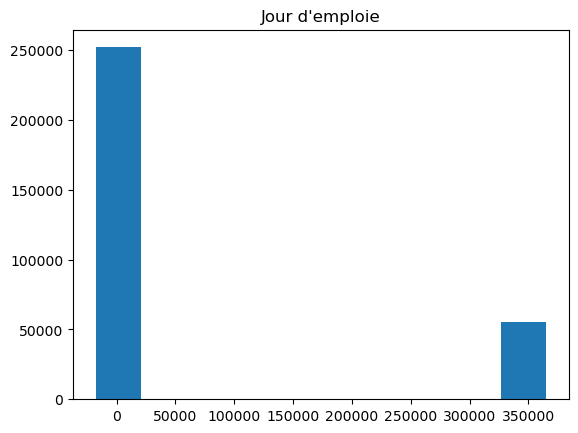

In [209]:
plt.hist(train["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

In [200]:
train["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

Donc cette valeurs aberrante est partagé par 55374 personne. Il n'est donc pas envisageable de simplement supprimer ces lignes.  
Est-ce que la valeurs de `TARGET` est particuliers ?

In [207]:
anom = train[train['DAYS_EMPLOYED'] == 365243]
non_anom = train[train['DAYS_EMPLOYED'] != 365243]
print('Les points normaux présente un taux de défaut de remboursement de %0.2f%%' % (100 * non_anom['TARGET'].mean()))
print('Les points anormaux présente un taux de défaut de remboursement de %0.2f%%' % (100 * anom['TARGET'].mean()))

Les points normaux présente un taux de défaut de remboursement de 8.66%
Les points anormaux présente un taux de défaut de remboursement de 5.40%


Il semblerais que les points anormaux présente un taux de défaut plus faible que les autres. Donc cette valeurs semble être signifiante. On a donc envie de la remplacer avec une imputation tous en conservant l'information que les point était anormaux en créant une nouvelle colonne.

In [ ]:
# creer la colonne de flag annomalie
train['DAYS_EMPLOYED_ANOM'] = 0
mask = train["DAYS_EMPLOYED"] == 365243
train.loc[mask, "DAYS_EMPLOYED_ANOM"] = 1
train.loc[mask, "DAYS_EMPLOYED"] = np.nan

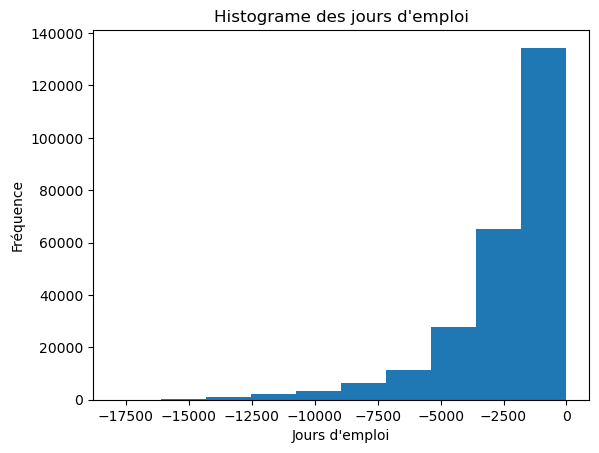

In [213]:
plt.hist(train["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

La transformation a fonctionner

Il faut aussi faire cette transformation pour le set de test

In [220]:
test["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    9274
-1119        32
-389         31
-1240        30
-148         28
Name: count, dtype: int64

In [219]:
anom = test[test['DAYS_EMPLOYED'] == 365243]
non_anom = test[test['DAYS_EMPLOYED'] != 365243]
print(f"Dans le jeu de test on trouve {non_anom.shape[0]} point normaux")
print(f"Dans le jeu de test on trouve {anom.shape[0]} point anormaux")

Dans le jeu de test on trouve 39470 point normaux
Dans le jeu de test on trouve 9274 point anormaux


In [221]:
# creer la colonne de flag annomalie
test['DAYS_EMPLOYED_ANOM'] = 0
mask = test["DAYS_EMPLOYED"] == 365243
test.loc[mask, "DAYS_EMPLOYED_ANOM"] = 1
test.loc[mask, "DAYS_EMPLOYED"] = np.nan

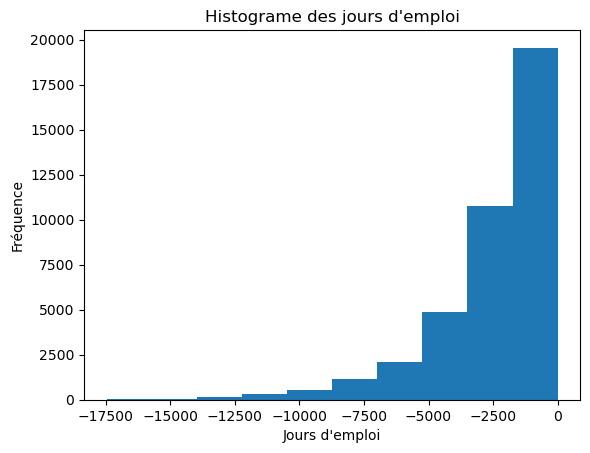

In [222]:
plt.hist(test["DAYS_EMPLOYED"])
plt.title("Histograme des jours d'emploi")
plt.xlabel("Jours d'emploi")
plt.ylabel("Fréquence")
plt.show()

# Encodage  
L'encodage des features ce fera dans le pipeline définit dans le notebook d'entraînement des modèles pour facilité le traitement. 

Encodage en one-hot encoder.  

Quand une feature qualitative ne contient que deux class on utilise le labelencoder
Sinon on utilse les autres type d'encodage poissibe, one-hot, Ordinal, Target.  

Faire une différence entre ces deux catégorie permet de limité le nombre de feature produite suite à l'encodage.  

Comment gérer les valeurs null de ces features ?

In [483]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

- Encodage du dataframe train

In [313]:
# Initialisation des encodeurs
le = LabelEncoder()
one_h = OneHotEncoder(sparse_output=False)

# Copier le dataframe
df = copy.copy(train)

# Boucler sur les colonnes
## Identifier les colonnes a encoder
object_columns = df.select_dtypes("object").columns

## Déterminer le nombre de class dans chaque colonne et isoler celle avec strictement moins de 3 class
tow_class_columns = []
more_class_columns = []

for column in object_columns:
    n_class = len(
                df[column].unique()
                )
    
    if n_class < 3:
        tow_class_columns.append(column)
        
    elif n_class >= 2 :
        more_class_columns.append(column)

## Appliquer l'encodage
### Sur les feature a deux class
for column in tow_class_columns:
    df[column] = le.fit_transform(df[column])

### Sur les features avec plus de 2 class
encoded_more_class_columns = one_h.fit_transform(df.loc[:, more_class_columns])
### Constuire un dataframe avec la sortie
encoded_more_class_columns = pd.DataFrame(encoded_more_class_columns, columns=one_h.get_feature_names_out(), index=df.index)
### Ajouter ce dataframe à l'original
df = pd.concat([df, encoded_more_class_columns], axis=1)
### Supprimer les colonnes devenue inutile
df = df.drop(more_class_columns, axis=1)

In [314]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307505 entries, 0 to 307510
Columns: 247 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(202), int64(45)
memory usage: 581.8 MB


In [315]:
encoded_train = copy.copy(df)

In [316]:
encoded_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307505 entries, 0 to 307510
Columns: 247 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(202), int64(45)
memory usage: 581.8 MB


- Encodage du dataframe de test

In [317]:
del df

In [318]:
# Initialisation des encodeurs
le = LabelEncoder()
one_h = OneHotEncoder(sparse_output=False)

# Copier le dataframe
df = copy.copy(test)

# Boucler sur les colonnes
## Identifier les colonnes a encoder
object_columns = df.select_dtypes("object").columns

## Déterminer le nombre de class dans chaque colonne et isoler celle avec strictement moins de 3 class
tow_class_columns = []
more_class_columns = []

for column in object_columns:
    n_class = len(
                df[column].unique()
                )
    
    if n_class < 3:
        tow_class_columns.append(column)
        
    elif n_class >= 2 :
        more_class_columns.append(column)

## Appliquer l'encodage
### Sur les feature a deux class
for column in tow_class_columns:
    df[column] = le.fit_transform(df[column])

### Sur les features avec plus de 2 class
encoded_more_class_columns = one_h.fit_transform(df.loc[:, more_class_columns])
### Constuire un dataframe avec la sortie
encoded_more_class_columns = pd.DataFrame(encoded_more_class_columns, columns=one_h.get_feature_names_out(), index=df.index)
### Ajouter ce dataframe à l'original
df = pd.concat([df, encoded_more_class_columns], axis=1)
### Supprimer les colonnes devenue inutile
df = df.drop(more_class_columns, axis=1)

In [319]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 245 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_nan
dtypes: float64(201), int64(44)
memory usage: 91.1 MB


In [320]:
encoded_test = copy.copy(df)
del df

In [321]:
encoded_train.shape

(307505, 247)

In [322]:
encoded_test.shape

(48744, 245)

Le nombre de colonne n'est plus le même entre les deux dataframe. Pour réaliser la modélisation il faut qu'il soit identique.

In [323]:
train_labels = encoded_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
encoded_train, encoded_test = encoded_train.align(encoded_test, join = 'inner', axis = 1)

# Add the target back in
encoded_train['TARGET'] = train_labels

print('Training Features shape: ', encoded_train.shape)
print('Testing Features shape: ', encoded_test.shape)

Training Features shape:  (307505, 246)
Testing Features shape:  (48744, 245)


Ce-fessant on retire une des class de certaine feature du dataframe.

Encodage en target encoder

# 4. Corrélation

Mesurer la corrélation entre les différentes features permet d'observer les relations entre les variables et la cible mais aussi entre les différentes variable.  
- Dans le cas de la corrélation avec la cible, de manière générale une feature très corréler seras souvent une feature très explicative de la cible.
- Dans le cas des variables entre elle, si celle-ci sont très corréler il peut être envisager de les combiner ou de leurs appliquer des transformation pour réduire la dimension du jeu de données. A l'inverse des variables très peut corréler entre elle sont très intéressante car elle apportent des informations différentes.

In [324]:
# Find correlations with the target and sort
correlations = encoded_train.corr()['TARGET'].sort_values()

In [327]:
correlations = correlations.sort_values()

In [328]:
correlations.head(15)

EXT_SOURCE_3                           -0.178926
EXT_SOURCE_2                           -0.160470
EXT_SOURCE_1                           -0.155316
NAME_EDUCATION_TYPE_Higher education   -0.056592
NAME_INCOME_TYPE_Pensioner             -0.046212
DAYS_EMPLOYED_ANOM                     -0.045990
ORGANIZATION_TYPE_XNA                  -0.045990
FLOORSMAX_AVG                          -0.044007
FLOORSMAX_MEDI                         -0.043771
FLOORSMAX_MODE                         -0.043230
EMERGENCYSTATE_MODE_No                 -0.042200
HOUSETYPE_MODE_block of flats          -0.040592
AMT_GOODS_PRICE                        -0.039647
OCCUPATION_TYPE_nan                    -0.038690
REGION_POPULATION_RELATIVE             -0.037225
Name: TARGET, dtype: float64

In [329]:
correlations.tail(15)

OCCUPATION_TYPE_Laborers                             0.043016
FLAG_DOCUMENT_3                                      0.044338
REG_CITY_NOT_LIVE_CITY                               0.044394
FLAG_EMP_PHONE                                       0.045985
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049820
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER                                          0.054711
DAYS_LAST_PHONE_CHANGE                               0.055220
NAME_INCOME_TYPE_Working                             0.057482
REGION_RATING_CLIENT                                 0.058901
REGION_RATING_CLIENT_W_CITY                          0.060895
DAYS_EMPLOYED                                        0.074959
DAYS_BIRTH                                           0.078244
TARGET                                               1.000000
Name: TARGET, dtype: float64

Les features les plus corréler au la target sont :
- `EXT_SOURCE_3/2/1` en négatif.
- `DAYS_BIRTH` et `DAYS_IMPLOYED` en positif.

## Effet de l'âge sur remboursement des prêts

In [330]:
encoded_train['DAYS_BIRTH'] = abs(encoded_train['DAYS_BIRTH'])
encoded_train['DAYS_BIRTH'].corr(encoded_train['TARGET'])

np.float64(-0.07824384822893396)

En ce basant sur ce coefficient de corrélation on peut dire que il a une relation inversement proportionnel entre le reboursement des prêt et l'âge. C'est a dire que les client les plus âgé on rembource un peut plus souvent leurs prêt que les plus jeune.

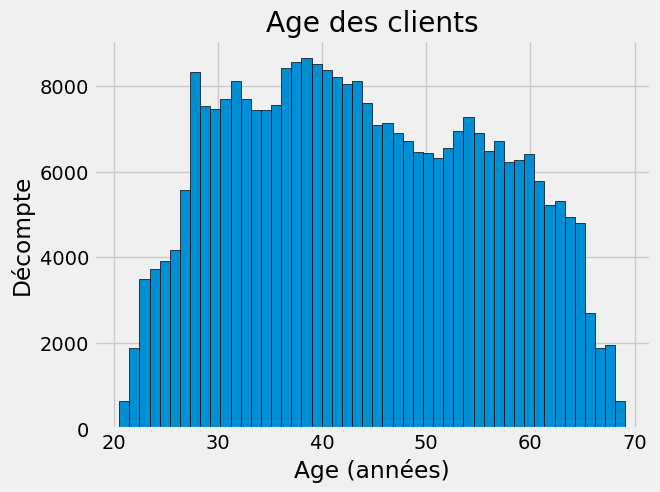

In [334]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(encoded_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 50)
plt.title('Age des clients'); plt.xlabel('Age (années)'); plt.ylabel('Décompte');

Cette représentation ne nous apporte pas d'information quand à l'effet de l'âge sur le remboursement du prêt

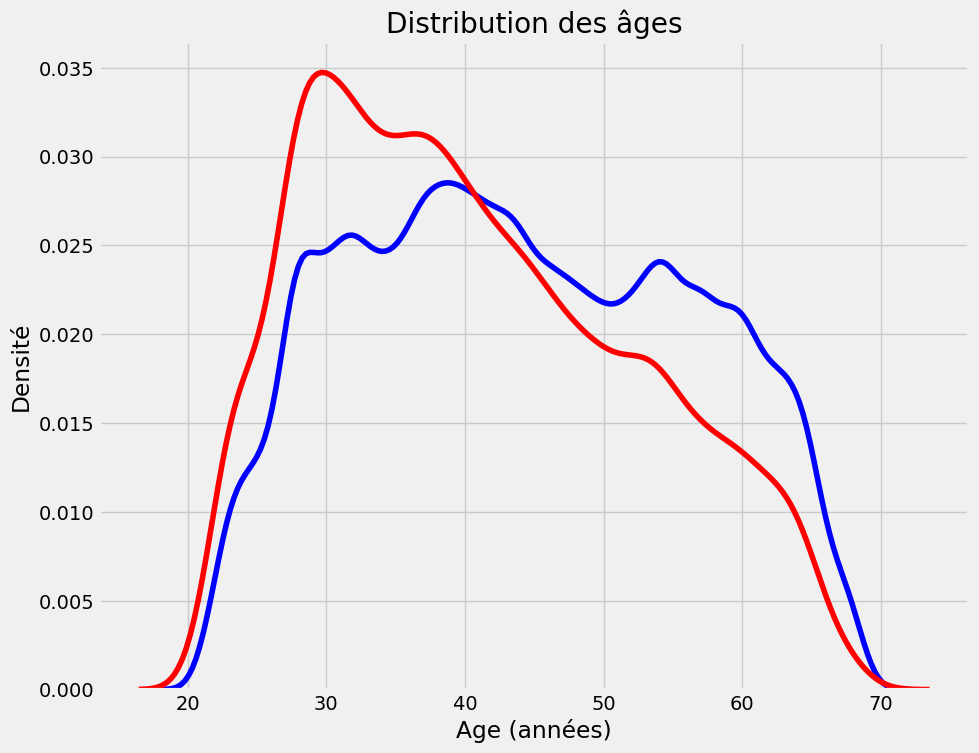

In [339]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0', color="Blue")

# KDE plot of loans which were not repaid on time
sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1', color="red")

# Labeling of plot
plt.xlabel('Age (années)'); plt.ylabel('Densité'); plt.title('Distribution des âges');

On observe une sureprésentation des défaut de remboursement chez les jeunes (la courbe rouge est au dessus de la bleu), et l'inverse dans le cas des clients les plus âgés. L'âge semble bien avoir un effet sur notre variable cible.

On peut discrétiser la variable puis calculer le taux moyen de non rembourssemet par plage d'âge.v

In [340]:
# Age information into a separate dataframe
age_data = encoded_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))

# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()

C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\377988952.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365
C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\377988952.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\377988952.py:9: FutureWarning: The default of observed=False is deprecated and will be

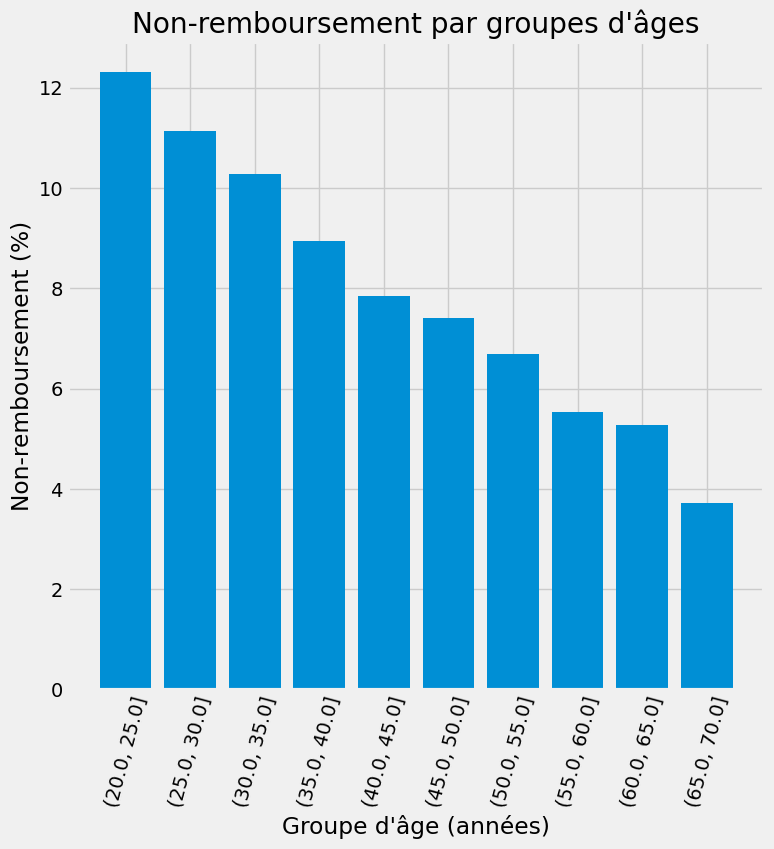

In [342]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel("Groupe d'âge (années)"); plt.ylabel('Non-remboursement (%)')
plt.title("Non-remboursement par groupes d'âges");

On observe bien un taux de rembourssement plus faible chez 20 25 ans, et ce taux s'améliore alors que l'âge des clients augmente.

## Sources extérieur

Les trois variables présentant les corrélations négatives les plus fortes avec la variable cible sont `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3`.

D'après la documentation, ces variables représentent un « score normalisé issu d'une source de données externe ». Je ne sais pas exactement ce que cela signifie, mais il pourrait s'agir d'une sorte de notation cumulative établie à partir de nombreuses sources de données.

Examinons ces variables.

Tout d'abord, nous pouvons afficher les corrélations des variables `EXT_SOURCE` avec la variable cible et entre elles.

In [344]:
# Extraire les sources externes du dataframe puis calculer leurs corrélation entre elles la target et la variables DAYS_BIRTH
ext_data = encoded_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155316,-0.160470,-0.178926,-0.078244
EXT_SOURCE_1,-0.155316,1.000000,0.213979,0.186845,0.600625
EXT_SOURCE_2,-0.160470,0.213979,1.000000,0.109180,0.092014
EXT_SOURCE_3,-0.178926,0.186845,0.109180,1.000000,0.205468
DAYS_BIRTH,-0.078244,0.600625,0.092014,0.205468,1.000000


Les différentes sources externe sont corréler entre elle mais les coefficients reste faible. On remarque que la source externe 1 est très fortement corréler avec l'âge de clients.

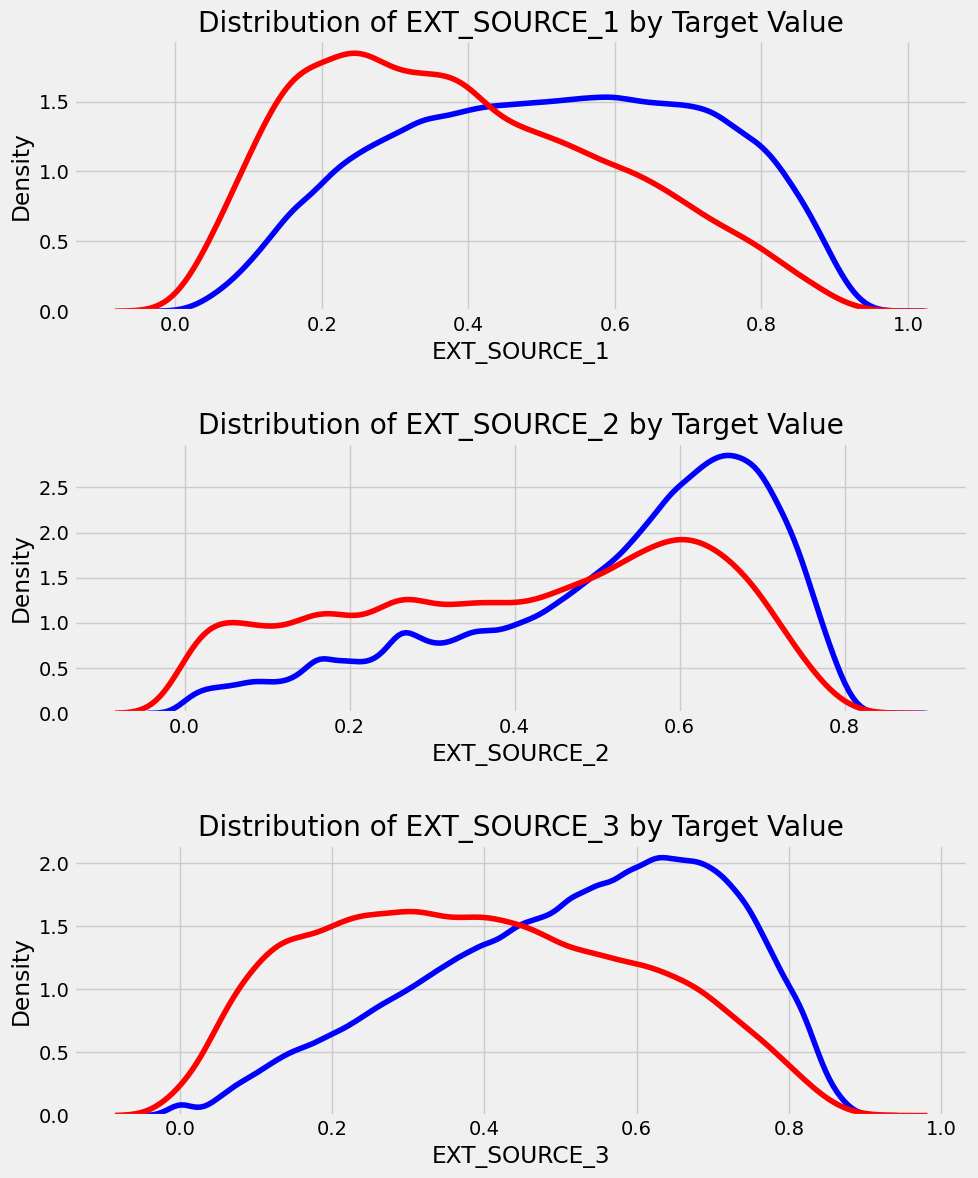

In [346]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 0, source], label = 'target == 0', color="blue")
    # plot loans that were not repaid
    sns.kdeplot(encoded_train.loc[encoded_train['TARGET'] == 1, source], label = 'target == 1', color="red")
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

Les sources externes on bien un effet sur la variables cible. globalement plus leurs valeurs est élevée plus les clients rembource leurs prêt.

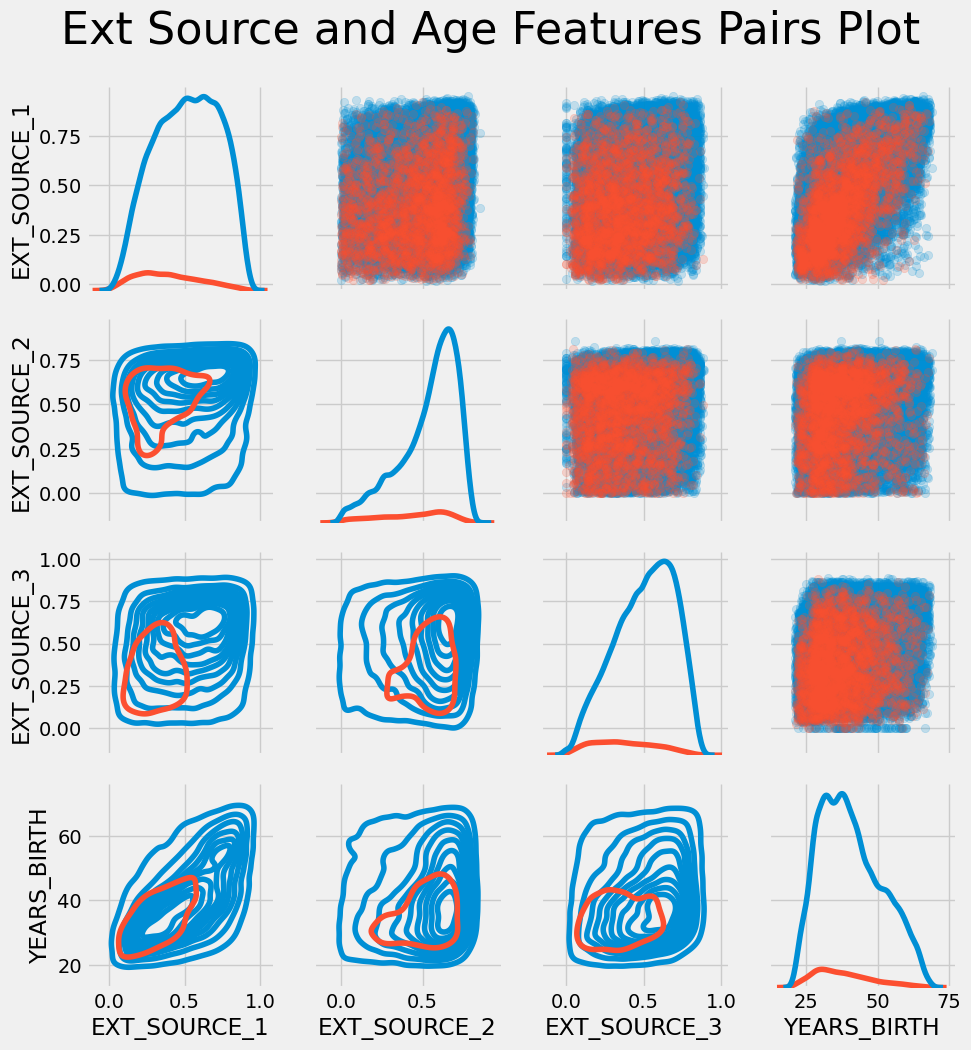

In [149]:
# Copy the data for plotting
plot_data = ext_data.drop(columns = ['DAYS_BIRTH']).copy()

# Add in the age of the client in years
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Drop na values and limit to first 100000 rows
plot_data = plot_data.dropna().loc[:100000, :]

# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size = 20)

# Create the pairgrid object
grid = sns.PairGrid(data = plot_data, 
                    #size = 3, 
                    diag_sharey=False,
                    hue = 'TARGET', 
                    vars = [x for x in list(plot_data.columns) if x != 'TARGET'])

# Upper is a scatter plot
grid.map_upper(plt.scatter, alpha = 0.2)

# Diagonal is a histogram
grid.map_diag(sns.kdeplot)

# Bottom is density plot
grid.map_lower(sns.kdeplot, cmap = plt.cm.OrRd_r);

plt.suptitle('Ext Source and Age Features Pairs Plot', size = 32, y = 1.05);

# 5. Feature engineering

Dans cette parti seul la feature génération sera étudier mais elle seras aussi encoder dans le pipeline de traitement pour facilité le déploiement.

In [362]:
# Make a new dataframe for polynomial features
poly_features = encoded_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = encoded_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

In [363]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307505, 35)


This creates a considerable number of new features. To get the names we have to use the polynomial features `get_feature_names` method.

In [364]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

There are 35 features with individual features raised to powers up to degree 3 and interaction terms. Now, we can see whether any of these new features are correlated with the target.

In [365]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Add in the target
poly_features['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.023984
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.023865
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.023852
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.022139
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.021583
EXT_SOURCE_2 DAYS_BIRTH                  -0.021346
EXT_SOURCE_1 EXT_SOURCE_2                -0.020694
EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH     -0.020597
EXT_SOURCE_2^2 DAYS_BIRTH                -0.020374
EXT_SOURCE_2                             -0.020145
Name: TARGET, dtype: float64
EXT_SOURCE_1^2   -0.011014
DAYS_BIRTH^3     -0.010862
EXT_SOURCE_1^3   -0.010109
TARGET            1.000000
1                      NaN
Name: TARGET, dtype: float64


Several of the new variables have a greater (in terms of absolute magnitude) correlation with the target than the original features. When we build machine learning models, we can try with and without these features to determine if they actually help the model learn. 

We will add these features to a copy of the training and testing data and then evaluate models with and without the features. Many times in machine learning, the only way to know if an approach will work is to try it out! 

In [366]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = encoded_train['SK_ID_CURR']
encoded_train_poly = encoded_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = encoded_test['SK_ID_CURR']
encoded_test_poly = encoded_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
encoded_train_poly, encoded_test_poly = encoded_train_poly.align(encoded_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', encoded_train_poly.shape)
print('Testing data with polynomial features shape:  ', encoded_test_poly.shape)

Training data with polynomial features shape:  (307505, 280)
Testing data with polynomial features shape:   (48744, 280)


## Domain Knowledge Features

Maybe it's not entirely correct to call this "domain knowledge" because I'm not a credit expert, but perhaps we could call this "attempts at applying limited financial knowledge". In this frame of mind, we can make a couple features that attempt to capture what we think may be important for telling whether a client will default on a loan. Here I'm going to use five features that were inspired by [this script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) by Aguiar:

* `CREDIT_INCOME_PERCENT`: the percentage of the credit amount relative to a client's income
* `ANNUITY_INCOME_PERCENT`: the percentage of the loan annuity relative to a client's income
* `CREDIT_TERM`:  the length of the payment in months (since the annuity is the monthly amount due
* `DAYS_EMPLOYED_PERCENT`: the percentage of the days employed relative to the client's age

Again, thanks to Aguiar and [his great script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) for exploring these features.



In [367]:
encoded_train_domain = encoded_train.copy()
encoded_test_domain = encoded_test.copy()

encoded_train_domain['CREDIT_INCOME_PERCENT'] = encoded_train_domain['AMT_CREDIT'] / encoded_train_domain['AMT_INCOME_TOTAL']
encoded_train_domain['ANNUITY_INCOME_PERCENT'] = encoded_train_domain['AMT_ANNUITY'] / encoded_train_domain['AMT_INCOME_TOTAL']
encoded_train_domain['CREDIT_TERM'] = encoded_train_domain['AMT_ANNUITY'] / encoded_train_domain['AMT_CREDIT']
encoded_train_domain['DAYS_EMPLOYED_PERCENT'] = encoded_train_domain['DAYS_EMPLOYED'] / encoded_train_domain['DAYS_BIRTH']

In [368]:
encoded_test_domain['CREDIT_INCOME_PERCENT'] = encoded_test_domain['AMT_CREDIT'] / encoded_test_domain['AMT_INCOME_TOTAL']
encoded_test_domain['ANNUITY_INCOME_PERCENT'] = encoded_test_domain['AMT_ANNUITY'] / encoded_test_domain['AMT_INCOME_TOTAL']
encoded_test_domain['CREDIT_TERM'] = encoded_test_domain['AMT_ANNUITY'] / encoded_test_domain['AMT_CREDIT']
encoded_test_domain['DAYS_EMPLOYED_PERCENT'] = encoded_test_domain['DAYS_EMPLOYED'] / encoded_test_domain['DAYS_BIRTH']

#### Visualize New Variables

We should explore these __domain knowledge__ variables visually in a graph. For all of these, we will make the same KDE plot colored by the value of the `TARGET`.

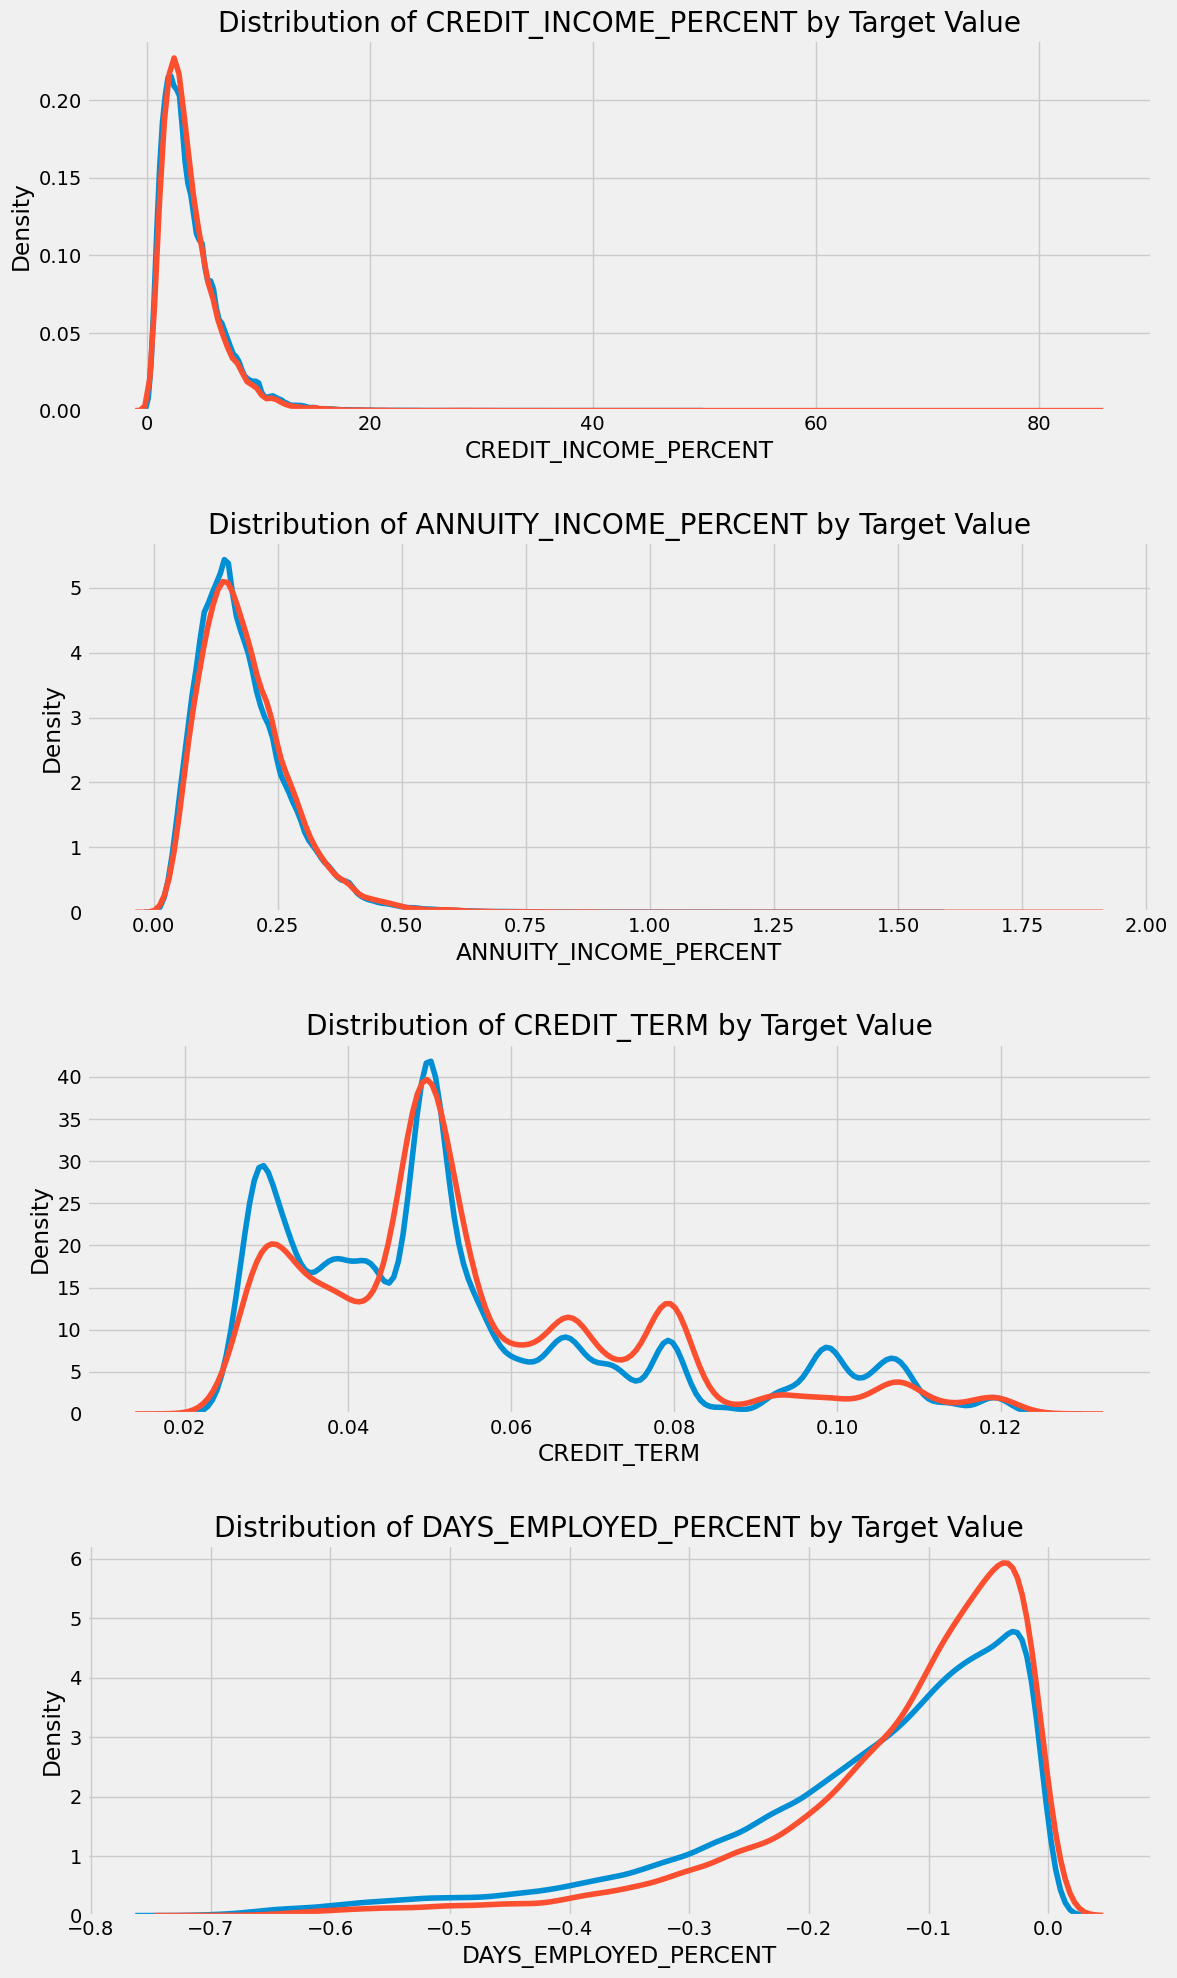

In [369]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(encoded_train_domain.loc[encoded_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(encoded_train_domain.loc[encoded_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

# 6. Modélisation rapide

In [ ]:
# Encoder certaine variables
# Réaliser le feature engineering
# Imputer les données manquantes
# Mettre à l'échelle les variables

In [479]:
from sklearn.pipeline import Pipeline

In [494]:
from sklearn.compose import ColumnTransformer

In [498]:
transformer = ColumnTransformer([
              ("Ordi_encoder", OrdinalEncoder(), tow_class_columns),
              ("one-hot_encoder", OneHotEncoder(), more_class_columns)
                ])

pipe = Pipeline([
              ("transformer", transformer),
              ("imputer", SimpleImputer(strategy = "median")),# Utiliser le KNN
              ("Scaler", MinMaxScaler()),
                ])

In [499]:
pipe

,steps,"[('transformer', ...), ('imputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Ordi_encoder', ...), ('one-hot_encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Préparer les données

In [370]:
from sklearn.preprocessing import MinMaxScaler

# Drop the target from the training data
if 'TARGET' in encoded_train:
    train = encoded_train.drop(columns = ['TARGET'])
else:
    train = encoded_train.copy()
    
# Feature names
features = list(train.columns)

# Copy of the testing data
test = encoded_test.copy()

# Median imputation of missing values
imputer = SimpleImputer(strategy = 'median')

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range = (0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)
test = imputer.transform(encoded_test)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (307505, 245)
Testing data shape:  (48744, 245)


Entraînement du modèle

In [371]:
from sklearn.linear_model import LogisticRegression

# Make the model with the specified regularization parameter
log_reg = LogisticRegression(C = 0.0001)

# Train on the training data
log_reg.fit(train, train_labels)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.0001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [379]:
# Make predictions
# Make sure to select the second column only
log_reg_pred = log_reg.predict_proba(train)[:, 1]

In [502]:
log_reg.classes_

array([0, 1])

In [380]:
# Submission dataframe
submit = encoded_train[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()

C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\2628033968.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['TARGET'] = log_reg_pred


,SK_ID_CURR,TARGET
0,100002,0.128357
1,100003,0.048468
2,100004,0.090317
3,100006,0.103051
4,100007,0.108797


In [381]:
from sklearn.metrics import roc_curve

In [382]:
fpr, tpr, thresholds = roc_curve(train_labels, submit["TARGET"])

In [384]:
len(fpr)

43902

In [385]:
tpr

array([0.00000000e+00, 0.00000000e+00, 2.01409869e-04, ...,
       9.99959718e-01, 1.00000000e+00, 1.00000000e+00], shape=(43902,))

In [386]:
thresholds

array([       inf, 0.19570915, 0.18479716, ..., 0.0327961 , 0.03278411,
       0.02696512], shape=(43902,))

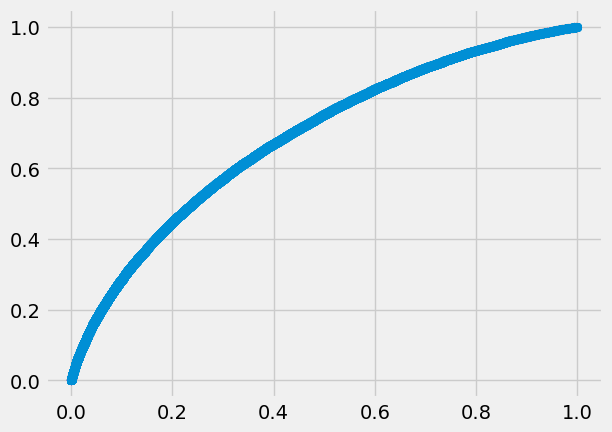

In [394]:
plt.scatter(fpr, tpr)
plt.show()

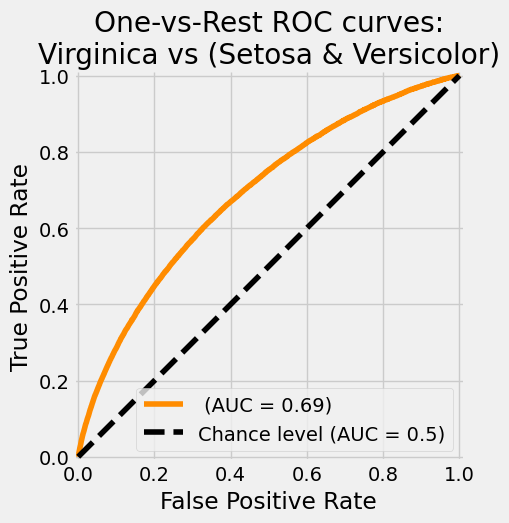

In [396]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    train_labels,
    submit["TARGET"],
    name=f"",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="One-vs-Rest ROC curves:\nVirginica vs (Setosa & Versicolor)",
)

C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\2278950790.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(thresholds, (tpr/fpr))


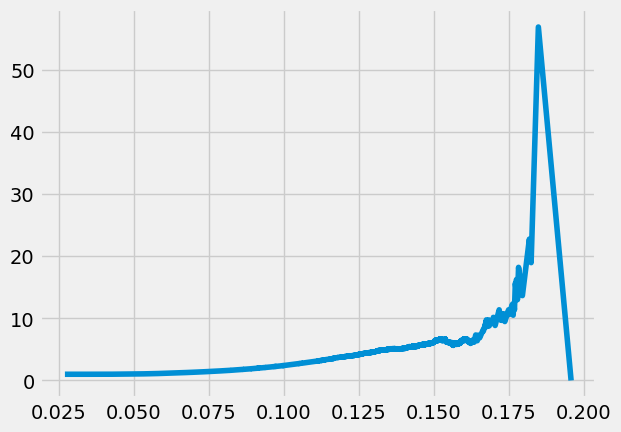

In [398]:
plt.plot(thresholds, (tpr/fpr))
plt.show()

C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\2420324163.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(thresholds, (fpr/tpr))
C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\2420324163.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(thresholds, (fpr/tpr))


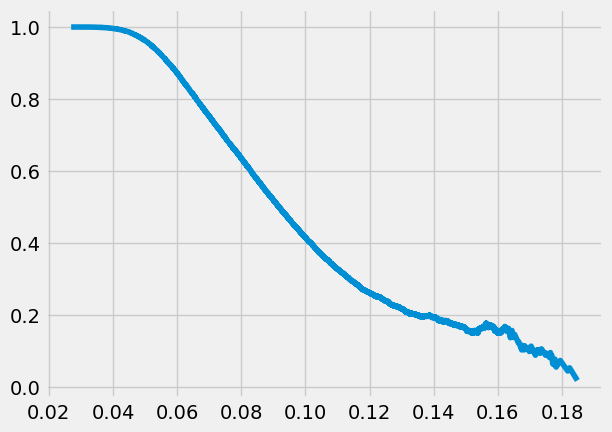

In [428]:
plt.plot(thresholds, (fpr/tpr))
plt.show()

In [413]:
test = tpr/fpr

C:\Users\SUZON\AppData\Local\Temp\ipykernel_20240\486177983.py:1: RuntimeWarning: invalid value encountered in divide
  test = tpr/fpr


In [414]:
test.min()

np.float64(nan)

In [411]:
test = test[~np.isnan(test)]

In [412]:
test.max()

np.float64(56.93454179254783)

In [418]:
thresholds = pd.Series(thresholds, name="seuil")

In [420]:
test = pd.Series(test, name="rapport")

In [424]:
temp = pd.DataFrame([thresholds, test], index=test.index)

ValueError: Length of values (2) does not match length of index (43902)

In [422]:
temp

,0,1,2,3,4,5,6,7,8,9,...,43892,43893,43894,43895,43896,43897,43898,43899,43900,43901
seuil,inf,0.195709,0.184797,0.182381,0.181796,0.17947,0.178192,0.177819,0.177501,0.177440,...,0.036643,0.036380,0.036376,0.035072,0.035046,0.034479,0.034476,0.032796,0.032784,0.026965
rapport,NaN,0.000000,56.934542,18.978181,22.773817,13.66429,18.219053,13.013610,16.267012,14.233635,...,1.001291,1.001117,1.001158,1.000580,1.000620,1.000468,1.000508,1.000126,1.000166,1.000000


In [427]:
temp.pivot(index=temp.columns, columns=temp.index)

ValueError: operands could not be broadcast together with shapes (43902,) (2,) 

In [430]:
test

0              NaN
1         0.000000
2        56.934542
3        18.978181
4        22.773817
           ...    
43897     1.000468
43898     1.000508
43899     1.000126
43900     1.000166
43901     1.000000
Name: rapport, Length: 43902, dtype: float64

In [466]:
fpr, tpr, thresholds = roc_curve(train_labels, submit["TARGET"])

In [467]:
submit["TARGET"].describe()

count    307505.000000
mean          0.080729
std           0.021061
min           0.026965
25%           0.064716
50%           0.078583
75%           0.094424
max           0.195709
Name: TARGET, dtype: float64

In [468]:
fpr = np.flip(fpr)

In [469]:
temp = pd.DataFrame.from_dict({"Seuil" : thresholds, "taux_faux_positif" : fpr, "taux_true_positif" : tpr})

In [470]:
temp["tfp/ttp"] = temp["taux_faux_positif"]/temp["taux_true_positif"]
temp["ttp/tfp"] = temp["taux_true_positif"]/temp["taux_faux_positif"]

In [471]:
temp

,Seuil,taux_faux_positif,taux_true_positif,tfp/ttp,ttp/tfp
0,inf,1.000000,0.000000,inf,0.000000e+00
1,0.195709,0.999834,0.000000,inf,0.000000e+00
2,0.184797,0.999834,0.000201,4964.174491,2.014434e-04
3,0.182381,0.999452,0.000201,4962.277575,2.015204e-04
4,0.181796,0.999452,0.000242,4135.231313,2.418244e-04
...,...,...,...,...,...
43897,0.034479,0.000011,0.999919,0.000011,9.421908e+04
43898,0.034476,0.000011,0.999960,0.000011,9.422287e+04
43899,0.032796,0.000004,0.999960,0.000004,2.826686e+05
43900,0.032784,0.000004,1.000000,0.000004,2.826800e+05


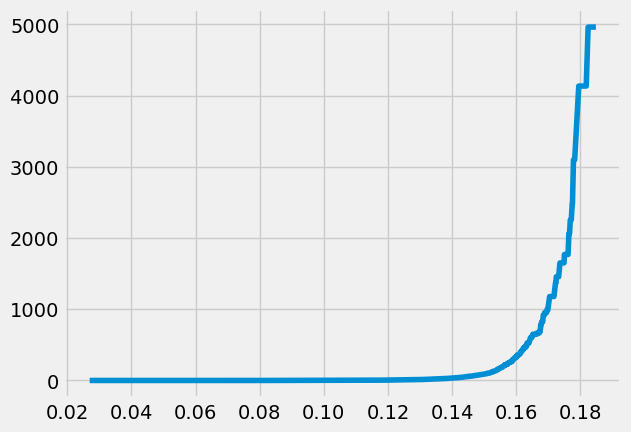

In [472]:
plt.plot(temp["Seuil"], temp["tfp/ttp"])

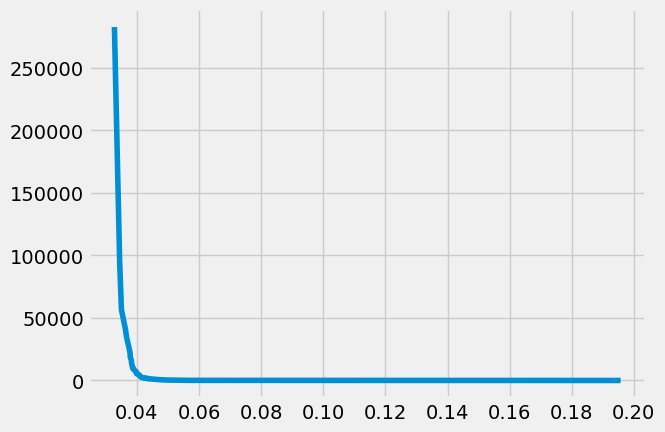

In [473]:
plt.plot(temp["Seuil"], temp["ttp/tfp"])

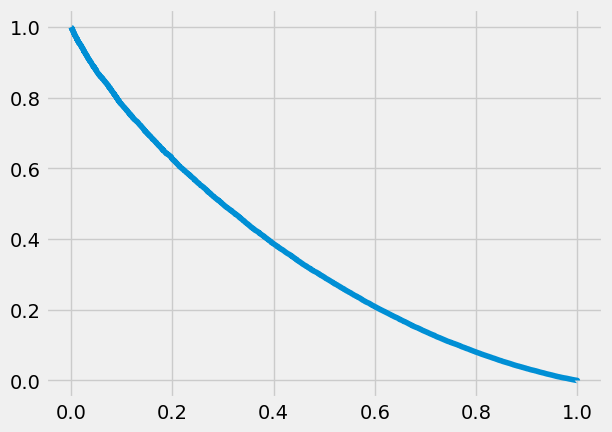

In [474]:
plt.plot(temp["taux_true_positif"], temp["taux_faux_positif"])

In [505]:
temp["score"] = 1*temp["taux_true_positif"] + 10*temp["taux_faux_positif"]

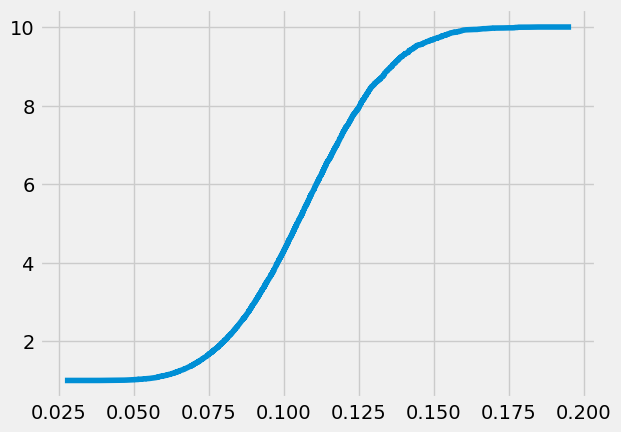

In [506]:
plt.plot(temp["Seuil"], temp["score"])

In [464]:
temp["score"].max()

np.float64(1.0)

In [465]:
temp.loc[temp["score"] == 1]

,Seuil,taux_faux_positif,taux_true_positif,tfp/ttp,ttp/tfp,score
43901,0.026965,1.0,1.0,1.0,1.0,1.0
